# Problema OneMax Armadilha (deceptive 4-bit Trap)

* A aptidão de uma solução é o número de 1s que ela contém, a menos que sejam todos 0s, caso em que sua aptidão é o tamnho da solução + 1;  
* Chamado de problema armadilha, uma vez que o algoritmo é recompensado gradativamente para cada 1 que adiciona ao problema, mas a melhor solução consiste em todos os 0s. 
    * Exemplo:
    * 1001 (soma == 2)
    * 0111 (soma == 3)
    * 1111 (soma == 4)
    * 0000 (soma == 5)

### Configuração do framework

In [49]:
# Configuração inicial
import six
import sys
sys.modules['sklearn.externals.six'] = six
import mlrose

### Definição da função fitness

In [50]:
def trap_fitness_function(solucao):
    """A soma dos valores 0s da solucao (list) e
       tamanho da cadeia de bits igual a 4.
    """

    soma = 0

    for bit in solucao:
        soma += bit

    if soma == 0:
        return 5
    else:
        return soma

### Construção do problema no mlrose

In [51]:
fitness = mlrose.CustomFitness(trap_fitness_function)

In [52]:
problema = mlrose.DiscreteOpt(length = 64, fitness_fn = fitness,
                             maximize = True, max_val = 2)

### Algoritmo Hill climbing

In [53]:
solucao_HC, melhor_custo, fitness_curve = mlrose.hill_climb(problema, curve=True)
solucao_HC, melhor_custo, fitness_curve

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       dtype=int32),
 np.float64(64.0),
 array([28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39., 40.,
        41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51., 52., 53.,
        54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64.]))

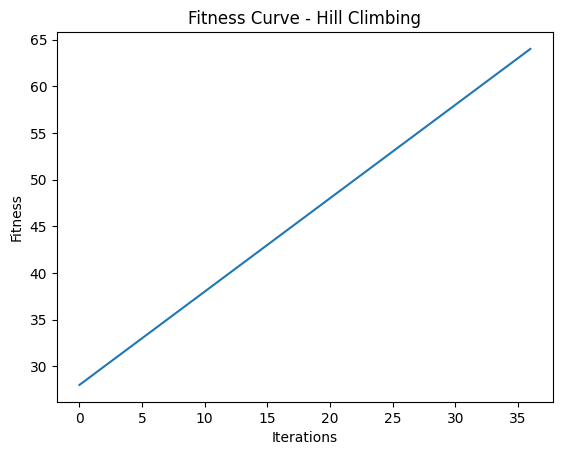

In [54]:
import matplotlib.pyplot as plt
plt.plot(fitness_curve)
plt.title('Fitness Curve - Hill Climbing')
plt.xlabel('Iterations')
plt.ylabel('Fitness')
plt.show()

### Algoritmo Simulated annealing

In [55]:
solucao_SA, melhor_custo, fitness_curve = mlrose.simulated_annealing(problema, curve=True)
solucao_SA, melhor_custo, fitness_curve

(array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
        0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1],
       dtype=int32),
 np.float64(48.0),
 array([31., 32., 32., 32., 31., 31., 32., 33., 32., 32., 33., 34., 33.,
        33., 33., 33., 33., 32., 32., 32., 33., 34., 35., 36., 37., 38.,
        38., 37., 37., 37., 37., 37., 37., 37., 38., 39., 40., 41., 41.,
        42., 42., 42., 42., 41., 41., 42., 43., 43., 44., 44., 44., 44.,
        43., 44., 44., 44., 44., 44., 44., 43., 43., 44., 43., 42., 42.,
        42., 42., 42., 41., 42., 42., 41., 41., 41., 42., 42., 41., 41.,
        42., 41., 42., 42., 42., 43., 43., 43., 42., 42., 42., 42., 43.,
        43., 44., 45., 44., 44., 44., 44., 45., 45., 45., 46., 46., 47.,
        47., 47., 48., 48., 48., 48., 48., 48., 48., 48., 48., 48., 48.]))

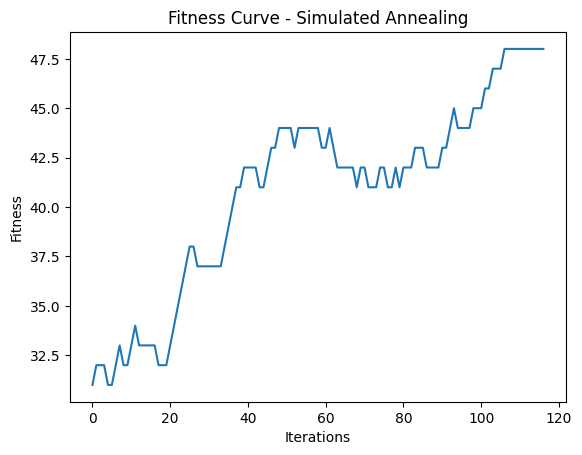

In [56]:
import matplotlib.pyplot as plt
plt.plot(fitness_curve)
plt.title('Fitness Curve - Simulated Annealing')
plt.xlabel('Iterations')
plt.ylabel('Fitness')
plt.show()